Fraud detection - Kaggle project

Library

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import prince
from sklearn.preprocessing import StandardScaler
from func import *

Dataset

In [2]:
df_transac = pd.read_csv('data/train_transaction.csv', nrows=50000)
df_id = pd.read_csv('data/train_identity.csv', nrows=50000)

print("Chargement partiel réussi !")
print(df_transac.head())
print(df_id.head())


Chargement partiel réussi !
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
4  514.0  150.0  mastercard  102.0  ...  0.0   0.0   0.0   0.0   0.0  0.0   

  V336  V337  V338  V339  
0  NaN   NaN   NaN 

In [3]:
# Check dimensions of the loaded dataframes
print(f"Dimensions df_transac : {df_transac.shape}")
print(f"Dimensions df_id : {df_id.shape}")

Dimensions df_transac : (50000, 394)
Dimensions df_id : (50000, 41)


In [4]:
print(df_transac.select_dtypes(include=['object']).columns)

Index(['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1',
       'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9'],
      dtype='str')


/var/folders/tm/ltl1_5rx0lq1ps9g4gbyst380000gn/T/ipykernel_73058/3687581855.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df_transac.select_dtypes(include=['object']).columns)


In [5]:
#Rate of isFraud in df_transac
fraud_rate = df_transac['isFraud'].mean() * 100
print(f"Percentage of fraudulent transactions : {fraud_rate:.2f}%")

Percentage of fraudulent transactions : 2.71%


In [6]:
df_transac.duplicated().sum()

np.int64(0)

We can firstly look if some columns have unique values, then we will remove them.

In [7]:
const_cols = [col for col in df_transac.columns if df_transac[col].nunique() == 1]

print(f"Constant columns: {const_cols}")

print(df_transac[const_cols].isnull().sum())

print(df_transac.groupby(const_cols)['isFraud'].mean())

Constant columns: ['M1', 'V107']
M1      32033
V107        0
dtype: int64
M1  V107
T   1.0     0.018423
Name: isFraud, dtype: float64


In [8]:
#Replace missing values in constant columns with -1
df_transac[const_cols] = df_transac[const_cols].fillna(0)

#Check if the Fraud rate is the same after replacing missing values and T in M1
print(df_transac.groupby(const_cols)['isFraud'].mean())

M1  V107
0   1.0     0.032029
T   1.0     0.018423
Name: isFraud, dtype: float64


For M1, the number of Fraud when M1 is False is 3.2% whereas it is only 1.8% when it is True.

We can remove V107 which has only one value.

In [9]:
df_transac = df_transac.drop(columns=['V107'])

In [10]:
print(df_transac['M1'].head())

0    T
1    0
2    T
3    0
4    0
Name: M1, dtype: object


Now, we will check the missing values

D7               95.288
dist2            93.290
D13              92.644
D12              91.806
D14              91.344
                  ...  
M1                0.000
isFraud           0.000
V104              0.000
V105              0.000
TransactionID     0.000
Length: 393, dtype: float64


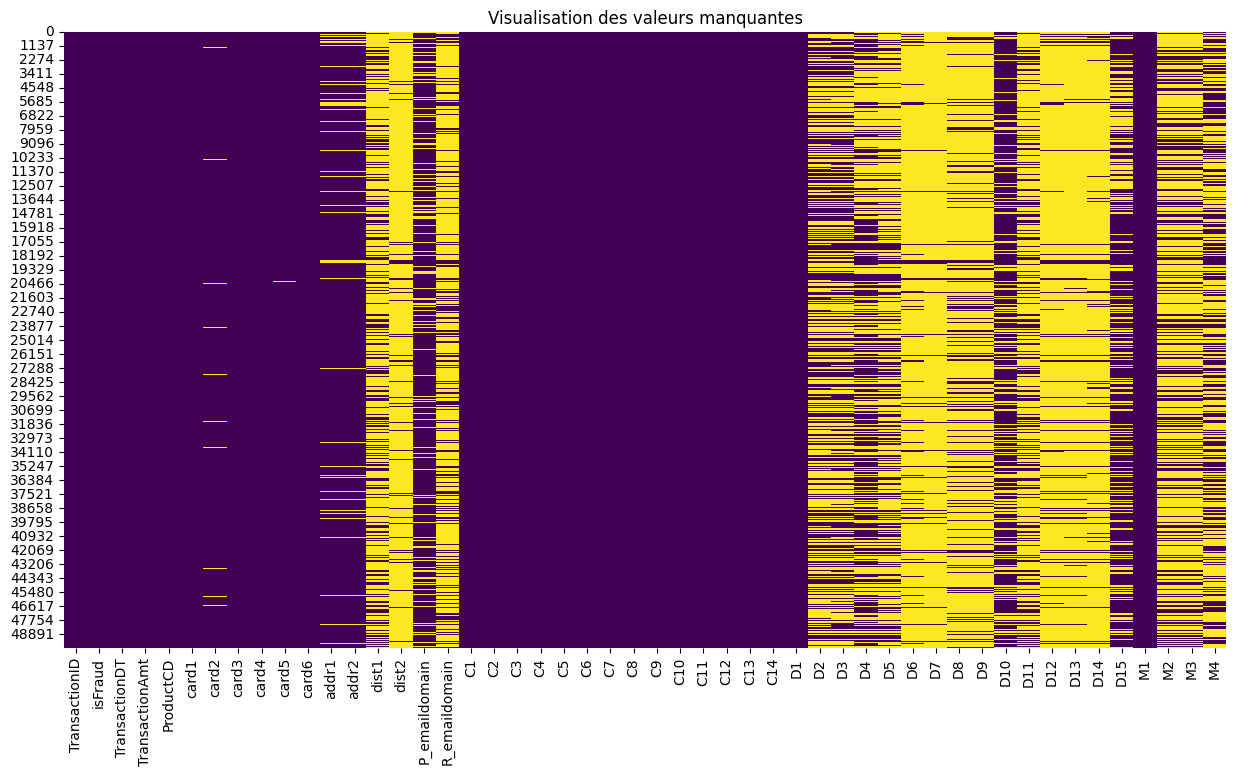

In [11]:
#Missing values check sorting

na_pourcentage = df_transac.isnull().mean() * 100
na_pourcentage.index = df_transac.columns
na_pourcentage = na_pourcentage.sort_values(ascending=False)
print(na_pourcentage)


# Visualise les 50 premières colonnes (pour ne pas saturer l'écran)
plt.figure(figsize=(15, 8))
sns.heatmap(df_transac.iloc[:, :50].isnull(), cbar=False, cmap='viridis')
plt.title("Visualisation des valeurs manquantes")
plt.show()

On a dataset with 50 000, we can remove variables with too much missing values.

Firstly, we will see if the missing values are information or not.

In [12]:
results = []

#loop to check the impact of missing values on the target variable 'isFraud'
for col in na_pourcentage.index:

    pourcentage = na_pourcentage[col]
    
    if pourcentage > 40:

        is_missing = df_transac[col].isnull().astype(int)
        
        fraud_rate_missing = df_transac[is_missing == 1]['isFraud'].mean() * 100
        fraud_rate_non_missing = df_transac[is_missing == 0]['isFraud'].mean() * 100

        diff = fraud_rate_missing - fraud_rate_non_missing

        ratio = (fraud_rate_missing / fraud_rate_non_missing) if fraud_rate_non_missing > 0 else float('inf')

        if diff == 0:
            print(f"The column {col} has no impact on the fraud rate.")
            df_transac = df_transac.drop(columns=[col])

        results.append({
            'column': col,
            'missing_percentage': pourcentage,
            'fraud_rate_missing': fraud_rate_missing,
            'fraud_rate_non_missing': fraud_rate_non_missing,
            'difference': diff,
            'ratio': ratio
        })

results_df = pd.DataFrame(results)
print(results_df.sort_values(by='difference', ascending=False))

    column  missing_percentage  fraud_rate_missing  fraud_rate_non_missing  \
8       M8              81.552            3.009123                1.409367   
9       M7              81.552            3.009123                1.409367   
10      M9              81.552            3.009123                1.409367   
187     M2              64.066            3.202947                1.842266   
186     M3              64.066            3.202947                1.842266   
..     ...                 ...                 ...                     ...   
5       D6              90.350            2.127283                8.207254   
4      D14              91.344            2.152303                8.641405   
2      D13              92.644            2.197660                9.216966   
3      D12              91.806            2.082653                9.787649   
0       D7              95.288            2.235329               12.393888   

     difference     ratio  
8      1.599756  2.135089  
9      

Now, we will proceed to an analysis by group. Let's start with variables C

In [13]:
#Analysis of variables C_ on the dataset df_transac

df_C = df_transac.filter(regex='^C', axis=1).copy()
print(df_C.head)

#summary of variables C_ in df_transac
print(df_C.describe())

<bound method NDFrame.head of         C1   C2   C3   C4   C5   C6   C7   C8   C9  C10  C11  C12   C13  C14
0      1.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  1.0  0.0  2.0  0.0   1.0  1.0
1      1.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0   1.0  1.0
2      1.0  1.0  0.0  0.0  0.0  1.0  0.0  0.0  1.0  0.0  1.0  0.0   1.0  1.0
3      2.0  5.0  0.0  0.0  0.0  4.0  0.0  0.0  1.0  0.0  1.0  0.0  25.0  1.0
4      1.0  1.0  0.0  0.0  0.0  1.0  0.0  1.0  0.0  1.0  1.0  0.0   1.0  1.0
...    ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   ...  ...
49995  4.0  3.0  0.0  0.0  3.0  4.0  0.0  0.0  3.0  0.0  4.0  0.0  76.0  2.0
49996  1.0  1.0  0.0  1.0  0.0  1.0  0.0  1.0  0.0  1.0  1.0  0.0   1.0  1.0
49997  1.0  1.0  0.0  0.0  1.0  1.0  0.0  0.0  0.0  0.0  1.0  0.0   1.0  1.0
49998  1.0  8.0  0.0  1.0  0.0  1.0  1.0  1.0  0.0  3.0  1.0  1.0   3.0  1.0
49999  1.0  1.0  0.0  1.0  0.0  1.0  0.0  1.0  0.0  1.0  1.0  0.0   1.0  1.0

[50000 rows x 14 columns]>
                 C

We will create a loop to see all variables C_, then we will know which variables are exactly the same, or how much they bring to predict a fraud. We will see the distribution with boxplot.

/Users/leadervieux/Documents/StageB/project/func.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/leadervieux/Documents/StageB/project/func.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/leadervieux/Documents/StageB/project/func.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/leadervieux/Documents/StageB/project/func.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


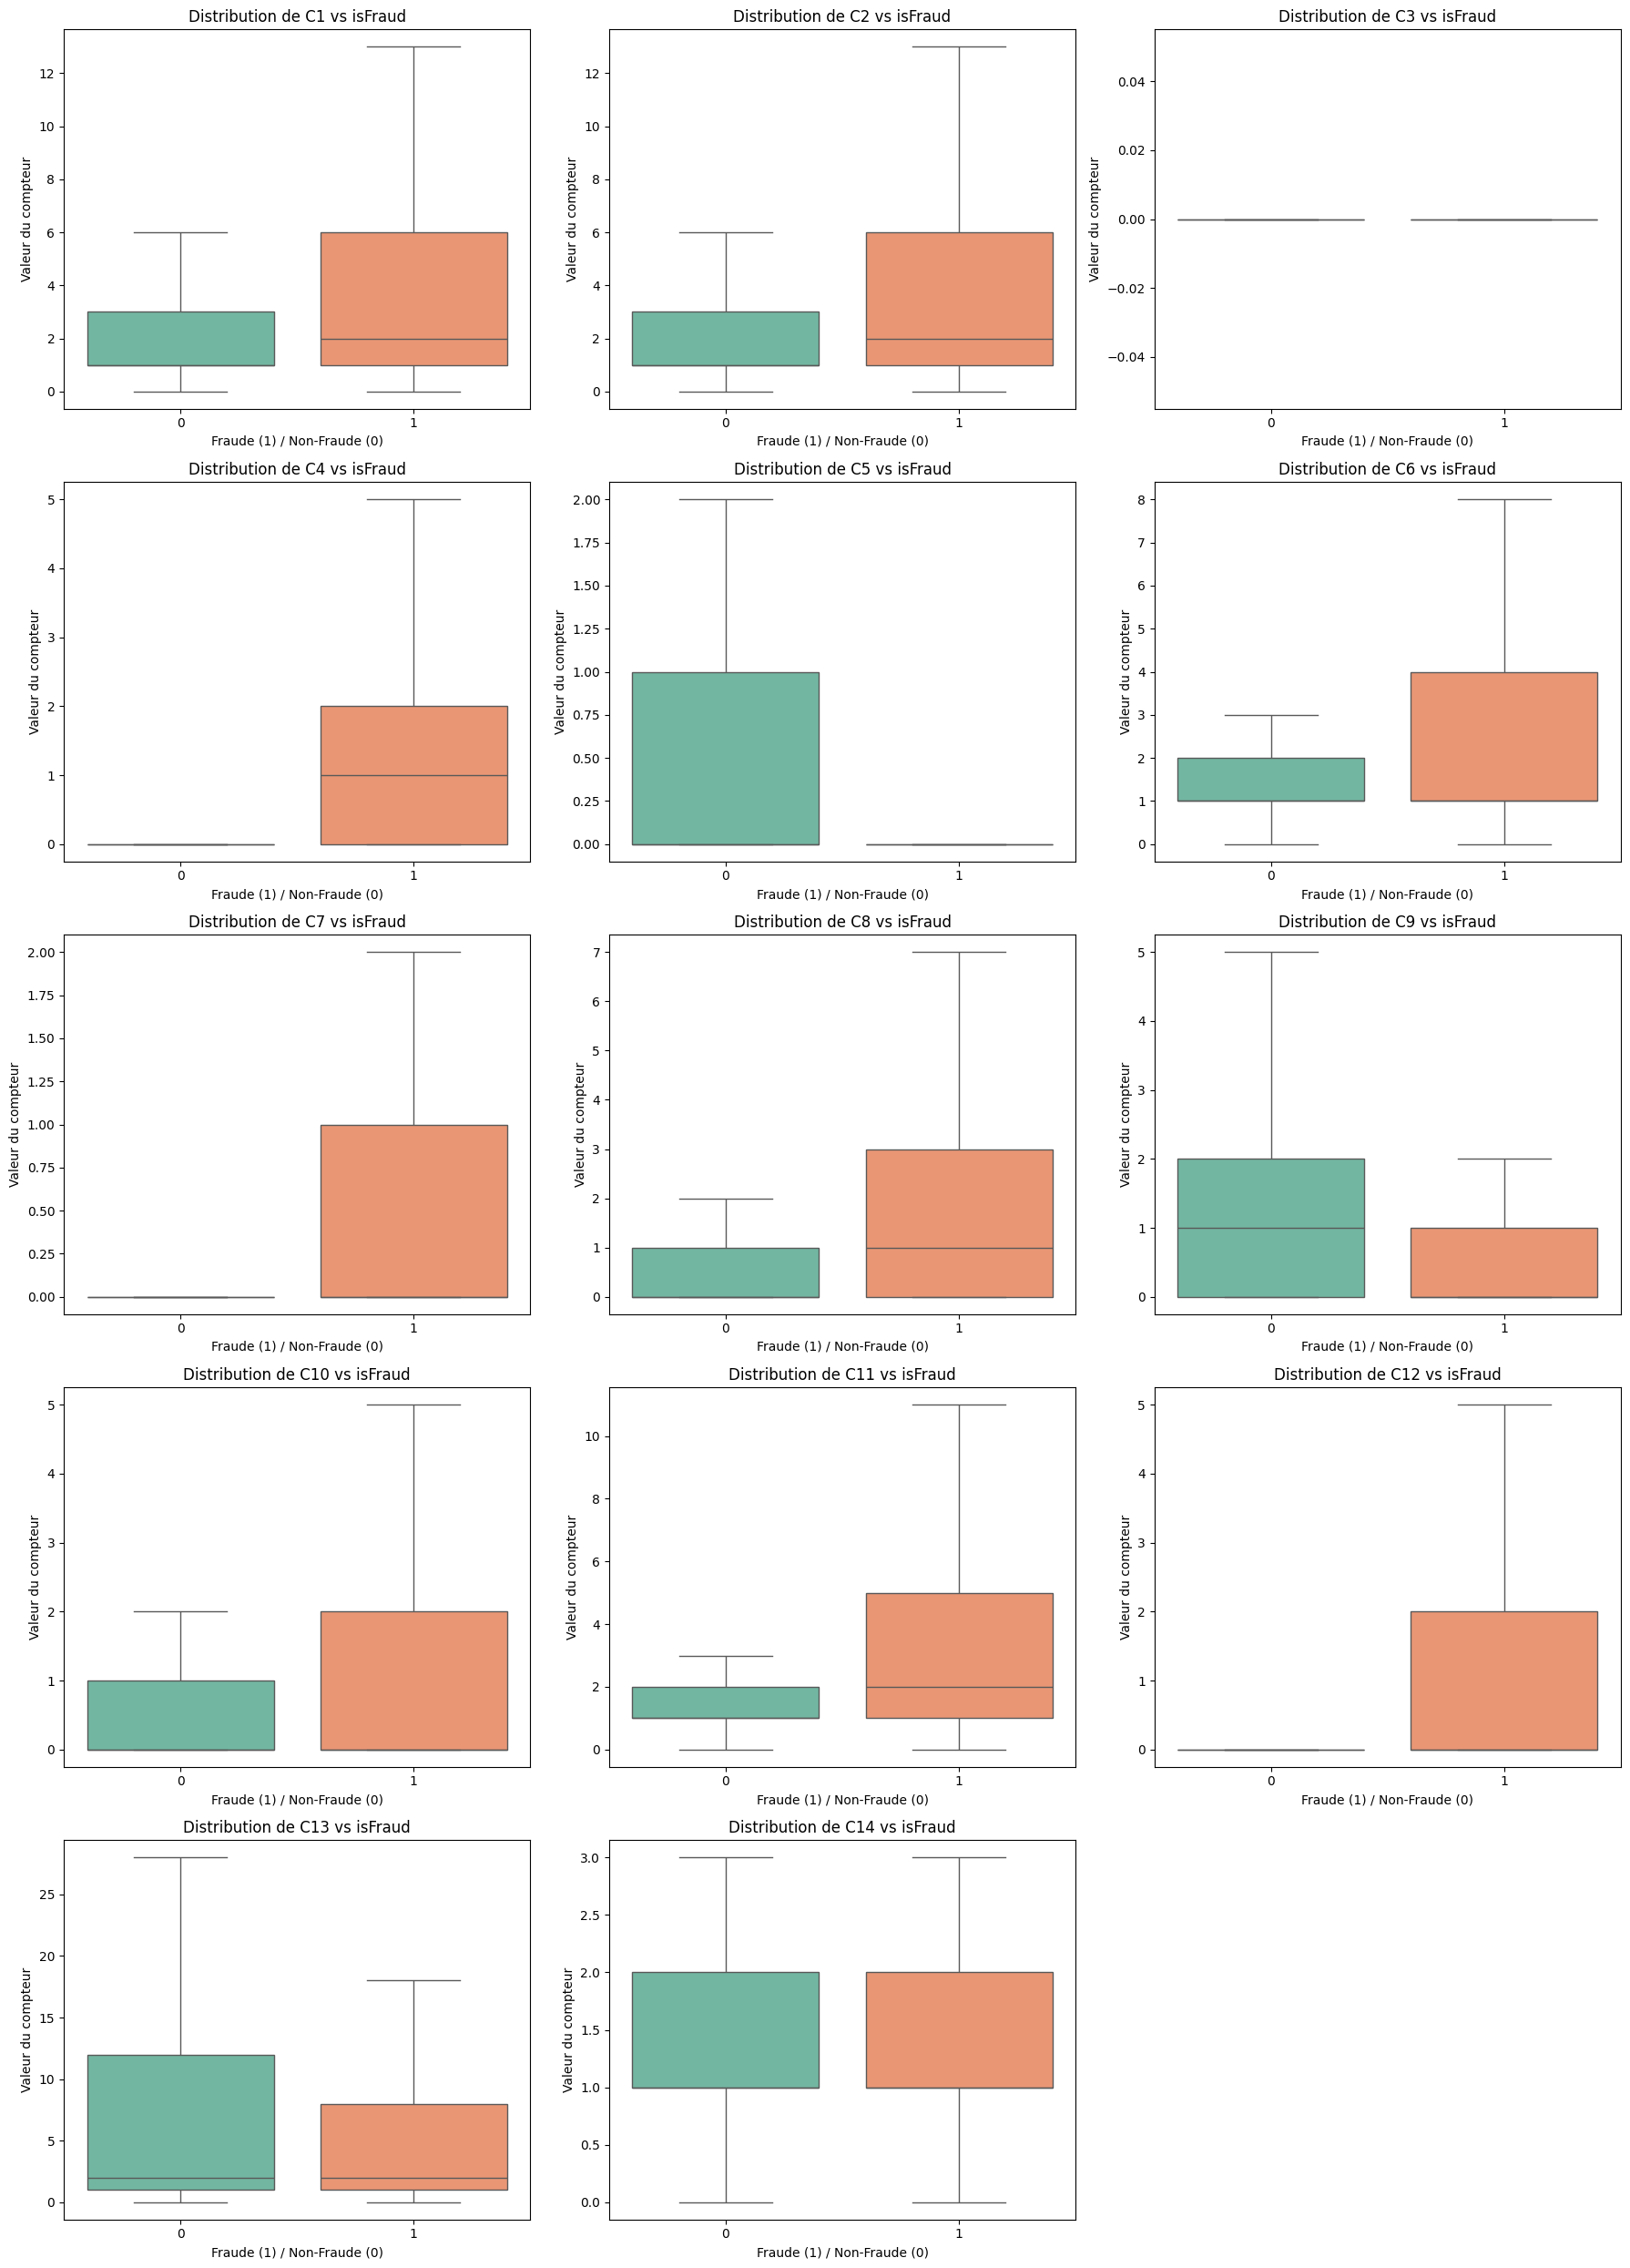

In [14]:
distribution(df_transac, 'C')

Variable C3 is useless.

C14 will not help us to predict frauds.

C1 and C2 have the exact same distribution.

C5 and C7 seem being the opposite.

 Variables like C5, C12, C7 can help to predict fraud because they have two completely different boxplots.

Zoom on correlation

['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']


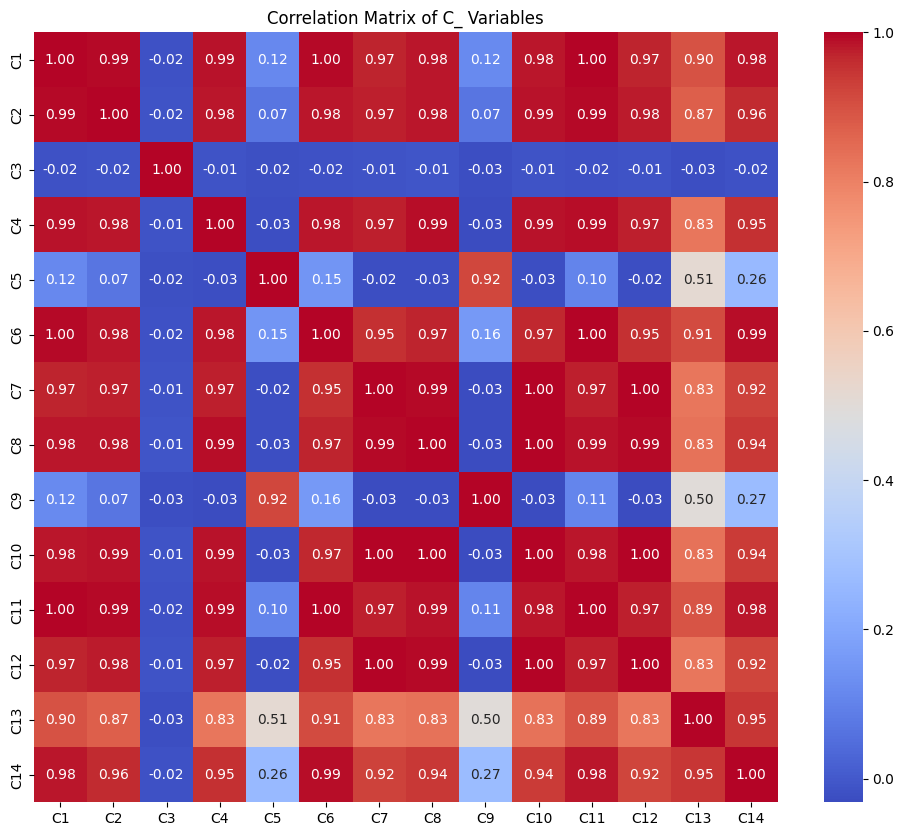

In [15]:
mat_corr(df_transac, 'C')

Here, correlation that are 1:

C1, C11 and C6;

C8 and C10;

C10, C12, and C7.

This is redondent.

In [16]:
#Is there a relationship between C3 and isFraud?
df_C3 = df_transac[['C3', 'isFraud']].copy()
df_C3['C3_non_zero'] = (df_C3['C3'] != 0).astype(int)
fraud_rate_C3_non_zero = df_C3[df_C3['C3_non_zero'] == 1]['isFraud'].mean() * 100
fraud_rate_C3_zero = df_C3[df_C3['C3_non_zero'] == 0]['isFraud'].mean() * 100
print(f"Fraud rate for C3 non-zero : {fraud_rate_C3_non_zero:.2f}%")
print(f"Fraud rate for C3 zero : {fraud_rate_C3_zero:.2f}%")


Fraud rate for C3 non-zero : 0.14%
Fraud rate for C3 zero : 2.75%


PCA on variables C

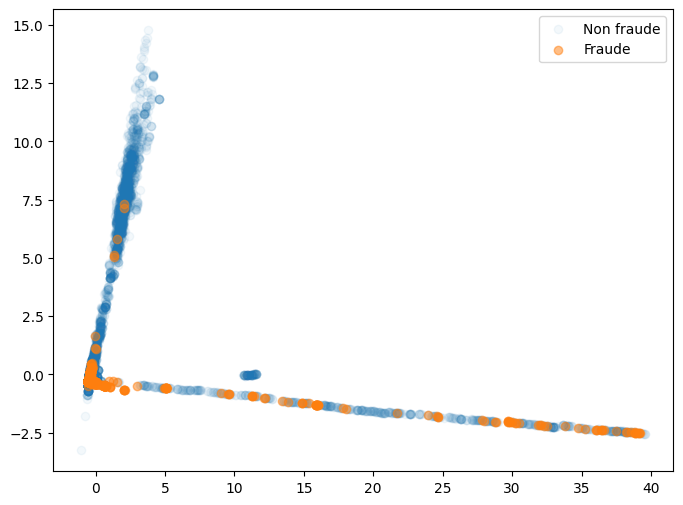

component         0         1
variable                     
C1         0.997674  0.001133
C2         0.992710 -0.049928
C3        -0.017732 -0.042822
C4         0.983926 -0.146820
C5         0.118314  0.971383
C6         0.993200  0.040101
C7         0.978774 -0.150197
C8         0.987158 -0.149711
C9         0.117373  0.971311
C10        0.986573 -0.150459
C11        0.998472 -0.011505
C12        0.978926 -0.150491
C13        0.903196  0.412409
C14        0.981121  0.155873           eigenvalue % of variance % of variance (cumulative)
component                                                    
0             10.603        75.73%                     75.73%
1              2.199        15.71%                     91.44%


In [17]:
col_coords, eigen_summary = PCA_func(df_transac, 'C', n_components=2)

print(col_coords, eigen_summary)

The point (0.0) is the heart of the activity, it is difficult to identify a fraud. However, there is a lot of outliers values, as we have points until 40 for the x-coordinate and 15 for the y-coordinate.
On the right, there are more orange points, then frauds have characteristics that permit to identify them compared to non fraud transactions, but some non fraud transactions are still different and can be confused with fraud transactions.

Variables C can be describe by only two dimensions: the first represents 75% of the initial information.
These variables are then redondent, we can explain 91% information with only 2 components.

Now we will analyze variables D.

In [18]:
#Analysis of variables D_ on the dataset df_transac

df_D = df_transac.filter(regex='^D', axis=1).copy()
print(df_D.head())

#summary of variables D_ in df_transac
print(df_D.describe())

      D1     D2    D3    D4   D5  D6  D7  D8  D9   D10    D11  D12  D13  D14  \
0   14.0    NaN  13.0   NaN  NaN NaN NaN NaN NaN  13.0   13.0  NaN  NaN  NaN   
1    0.0    NaN   NaN   0.0  NaN NaN NaN NaN NaN   0.0    NaN  NaN  NaN  NaN   
2    0.0    NaN   NaN   0.0  NaN NaN NaN NaN NaN   0.0  315.0  NaN  NaN  NaN   
3  112.0  112.0   0.0  94.0  0.0 NaN NaN NaN NaN  84.0    NaN  NaN  NaN  NaN   
4    0.0    NaN   NaN   NaN  NaN NaN NaN NaN NaN   NaN    NaN  NaN  NaN  NaN   

     D15  
0    0.0  
1    0.0  
2  315.0  
3  111.0  
4    NaN  
                 D1            D2            D3            D4            D5  \
count  50000.000000  23484.000000  24444.000000  26829.000000  17821.000000   
mean      81.400240    164.398229     28.190476    134.461553     39.503844   
std      139.516778    159.215459     58.501079    170.299796     77.880678   
min        0.000000      0.000000      0.000000   -122.000000      0.000000   
25%        0.000000     28.000000      1.000000      0.000

In [19]:
na_pourcentage = df_D.isnull().mean() * 100
na_pourcentage.index = df_D.columns
na_pourcentage = na_pourcentage.sort_values(ascending=False)
print(na_pourcentage)

D7     95.288
D13    92.644
D12    91.806
D14    91.344
D6     90.350
D8     82.500
D9     82.500
D11    69.404
D5     64.358
D2     53.032
D3     51.112
D4     46.342
D15    33.002
D10    24.340
D1      0.000
dtype: float64


/Users/leadervieux/Documents/StageB/project/func.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/leadervieux/Documents/StageB/project/func.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/leadervieux/Documents/StageB/project/func.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/leadervieux/Documents/StageB/project/func.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


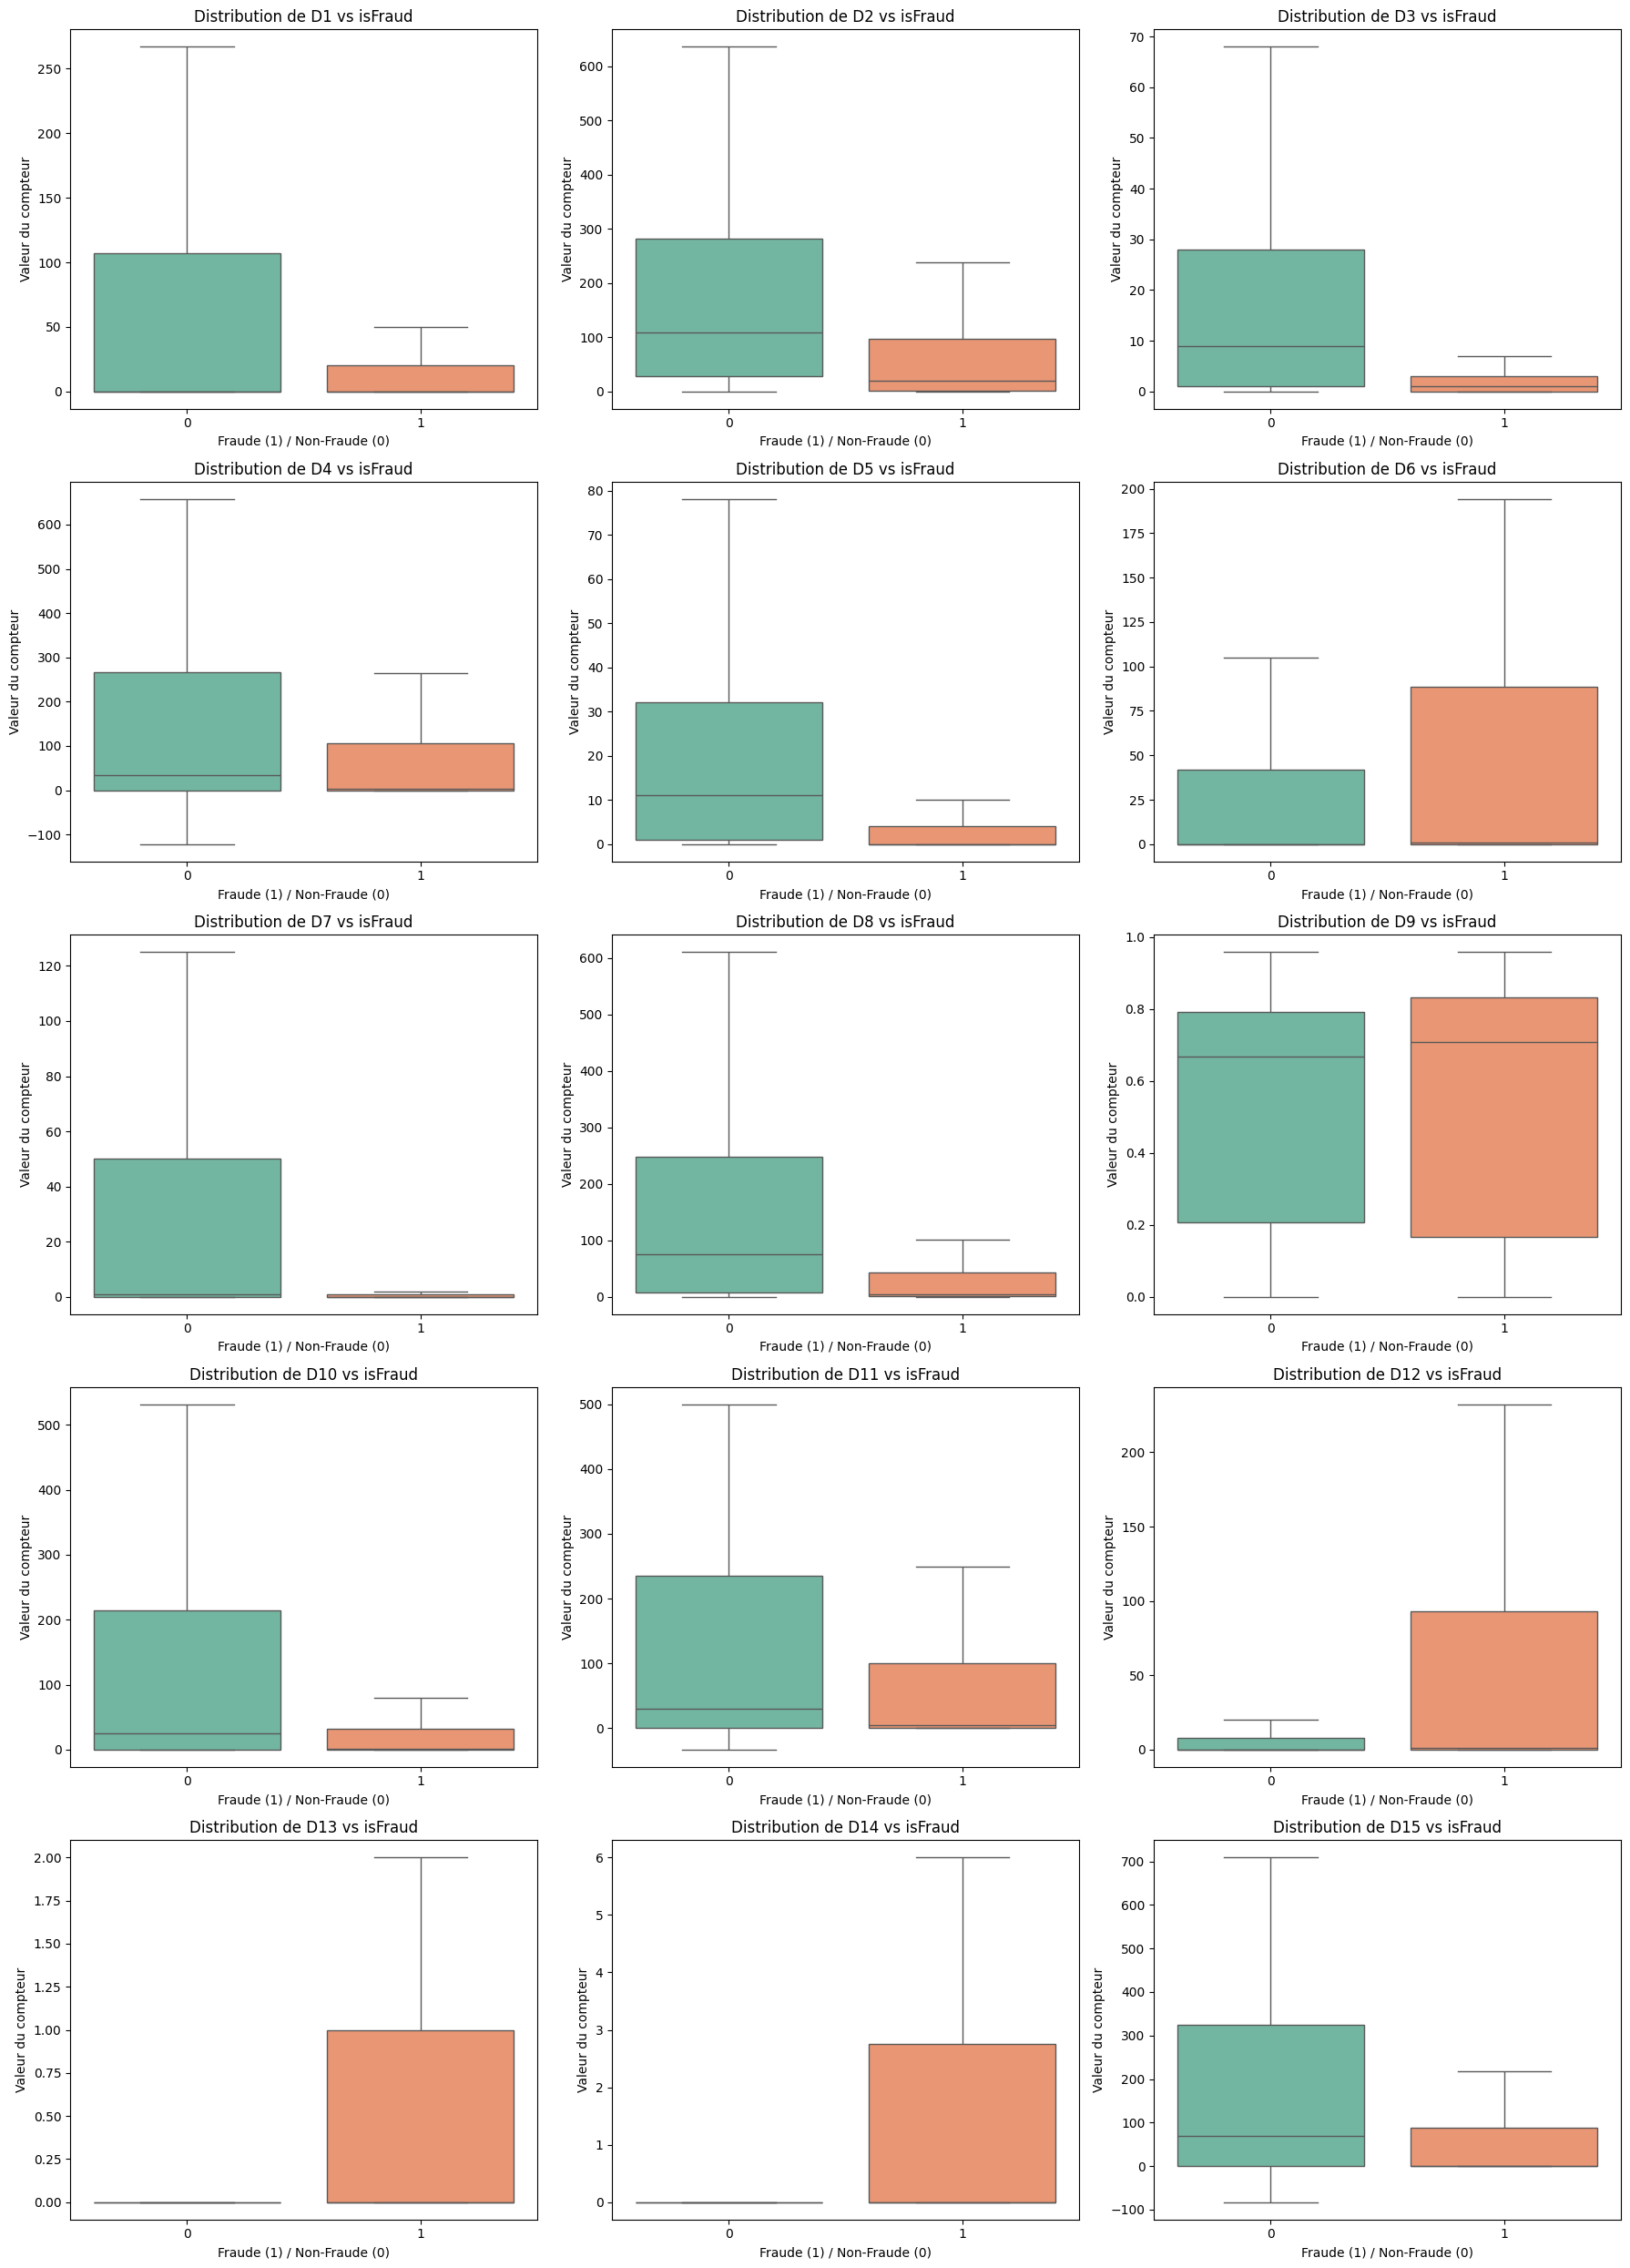

In [20]:
distribution(df_transac, 'D')

D13 and D14 have the same distribution, but not one the same scale.
D9 Fraud and not Fraud have also approximately the same distribution.
D13 and D14 are always fraud.
if there is a Fraud, D7 is more likely a 0. 
However, if there is not fraud, D13 and D14 are more likely a 0.

We will compute flags to delete NaN values.

In [21]:
cols_d = [c for c in df_transac.columns if c.startswith('D')]

new_columns = {}

for col in cols_d:

    new_columns[f'{col}_isMissing'] = df_transac[col].isna().astype(int)

df_flags = pd.DataFrame(new_columns)

df_transac = pd.concat([df_transac, df_flags], axis=1)

df_transac = df_transac.copy()

And replace the NaN values by the median of each variable.

In [22]:
df_transac[cols_d] = df_transac[cols_d].fillna(df_transac[cols_d].median())

['D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'D2_isMissing', 'D3_isMissing', 'D4_isMissing', 'D5_isMissing', 'D6_isMissing', 'D7_isMissing', 'D8_isMissing', 'D9_isMissing', 'D10_isMissing', 'D11_isMissing', 'D12_isMissing', 'D13_isMissing', 'D14_isMissing', 'D15_isMissing']


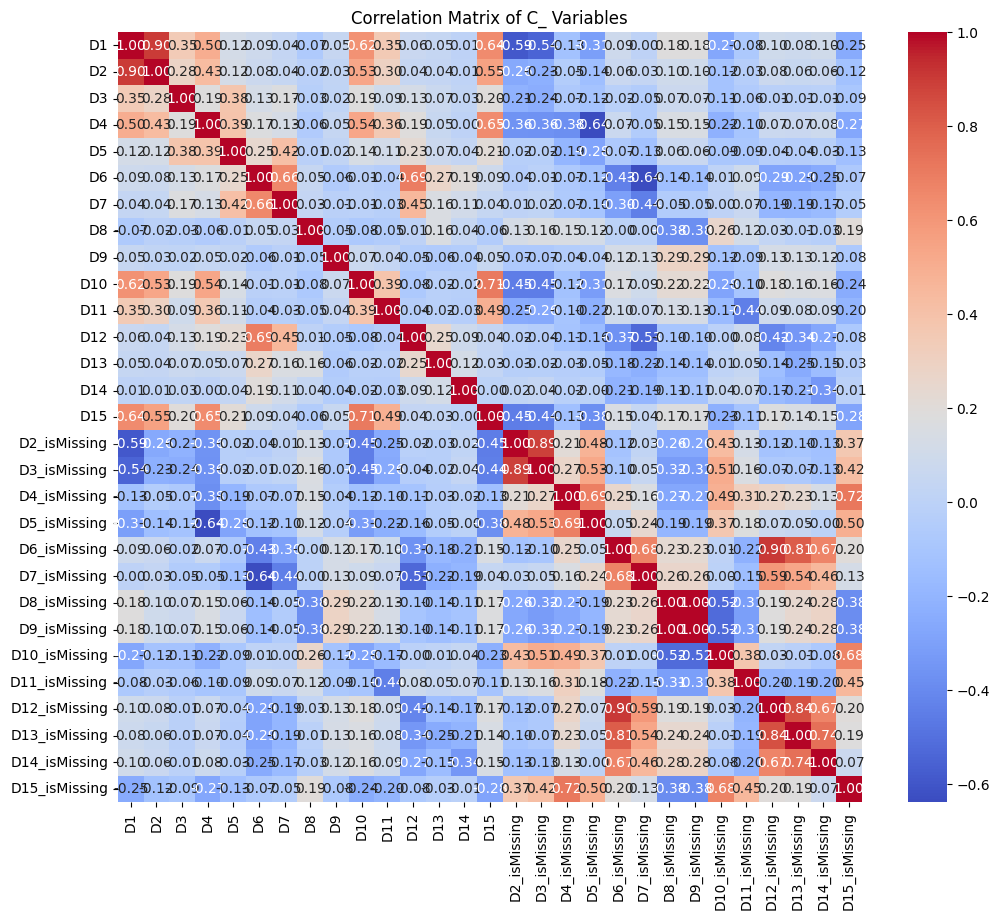

In [23]:
#analysis on correlation between D_ variables

#Correlation matrix of D_ variables
mat_corr(df_transac, 'D')

D5 and D7, and D2 D1 are also very close.

We can delete D9_isMissing because it is exactly the same values than D8_isMissing.

In [45]:
df_transac = df_transac.drop(columns=['D9_isMissing'])

KeyError: "['D9_isMissing'] not found in axis"

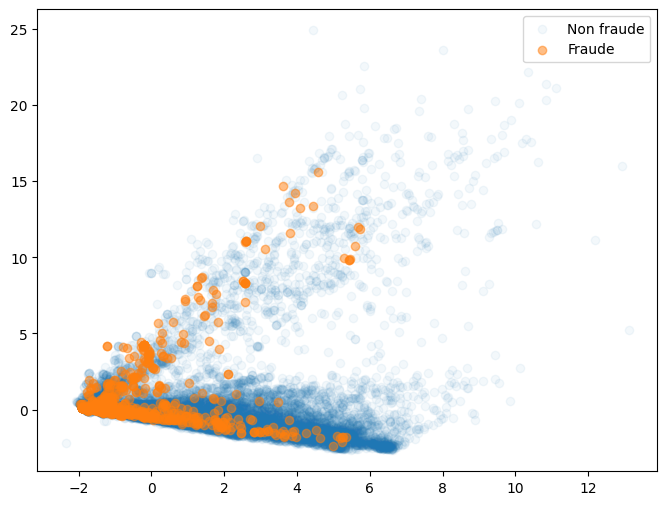

component         0         1         2         3         4         5  \
variable                                                                
D1         0.846110 -0.200981  0.167244  0.076752 -0.161862  0.195090   
D2         0.779910 -0.187618  0.208264  0.106823 -0.170532  0.198205   
D3         0.427518  0.174543 -0.267589  0.658737 -0.226710  0.130010   
D4         0.758108  0.011521 -0.090361 -0.134425  0.136793 -0.183740   
D5         0.408853  0.409896 -0.458052  0.351197  0.078321 -0.211206   
D6         0.268369  0.824976  0.064212 -0.249733 -0.012206  0.048564   
D7         0.240335  0.753749 -0.185249 -0.052982  0.039188 -0.032244   
D8        -0.074347  0.131807  0.532596  0.448031  0.507341 -0.201640   
D9         0.065552 -0.117355 -0.361371 -0.053659  0.646918  0.652005   
D10        0.756888 -0.309808  0.047837 -0.095264  0.042885 -0.027062   
D11        0.523097 -0.253591  0.001278 -0.213519  0.187364 -0.251691   
D12        0.218850  0.751503  0.018236 -0.267006 -

In [46]:
col_coords, eigen_summary = PCA_func(df_transac, 'D', n_components=10)

print(col_coords, eigen_summary)

Variables D are very independent, we can't really capt the pattern for Fraud and other.

For variables M

In [26]:
df_M = df_transac.filter(regex='^M', axis=1).copy()
print(df_M.head)

#summary of variables M_ in df_transac
print(df_M.describe())

<bound method NDFrame.head of       M1   M2   M3   M4   M5   M6   M7   M8   M9
0      T    T    T   M2    F    T  NaN  NaN  NaN
1      0  NaN  NaN   M0    T    T  NaN  NaN  NaN
2      T    T    T   M0    F    F    F    F    F
3      0  NaN  NaN   M0    T    F  NaN  NaN  NaN
4      0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
...   ..  ...  ...  ...  ...  ...  ...  ...  ...
49995  0  NaN  NaN   M0    T    T  NaN  NaN  NaN
49996  0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
49997  0  NaN  NaN  NaN  NaN    F  NaN  NaN  NaN
49998  0  NaN  NaN   M0  NaN  NaN  NaN  NaN  NaN
49999  0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN

[50000 rows x 9 columns]>
           M1     M2     M3     M4     M5     M6    M7    M8    M9
count   50000  17967  17967  22662  17826  31329  9224  9224  9224
unique      2      2      2      3      2      2     2     2     2
top         0      T      T     M0      F      F     F     F     T
freq    32033  16168  14030  14864   9749  17030  7933  5684  7888


We will transform all F values as 0 and T values as 1, then we will treat missing values. First, we will check M4 which has 3 unique values.

In [27]:
print(df_transac['M4'].unique())

<StringArray>
['M2', 'M0', nan, 'M1']
Length: 4, dtype: str


We will perform a One-Hot Encoding to transform M4 in multiple categories.

In [28]:
#One hot encoding of M4
df_transac['M4'] = df_transac['M4'].fillna('Missing')
df_transac = pd.get_dummies(df_transac, columns=['M4'], prefix='M4')


In [29]:
# Conversion des booléens en entiers (True -> 1, False -> 0)
cols_m4 = [col for col in df_transac.columns if col.startswith('M4_')]
df_transac[cols_m4] = df_transac[cols_m4].astype(int)

In [30]:
#Check if the conversion was successful
print(df_transac.filter(like='M4_').dtypes)
# print the created columns and some rows of data
colonnes_m4 = [col for col in df_transac.columns if col.startswith('M4_')]
print(df_transac[colonnes_m4].head())

M4_M0         int64
M4_M1         int64
M4_M2         int64
M4_Missing    int64
dtype: object
   M4_M0  M4_M1  M4_M2  M4_Missing
0      0      0      1           0
1      1      0      0           0
2      1      0      0           0
3      1      0      0           0
4      0      0      0           1


Now we need to convert the other variables, 1 for T and 0 for F.

In [31]:
#number of NA for M_ variables
na_pourcentage_M = df_transac.filter(regex='^M', axis=1).isnull().mean() * 100
na_pourcentage_M.index = df_transac.filter(regex='^M', axis=1).columns
na_pourcentage_M = na_pourcentage_M.sort_values(ascending=False)
print(na_pourcentage_M)

M7            81.552
M8            81.552
M9            81.552
M5            64.348
M2            64.066
M3            64.066
M6            37.342
M1             0.000
M4_M0          0.000
M4_M1          0.000
M4_M2          0.000
M4_Missing     0.000
dtype: float64


As we have a lot of missing values for each variable, we will have a look on the importance to predict fraud.

We will separate variable in two to distinguish missing values and the rest, then we will look the fraud rate for each column.

We remove M4 and M1 that are already sorted.

In [32]:
cols_m = [col for col in df_transac.columns if col.startswith('M')  and not col.startswith('M4') and not col.startswith('M1')]

# 2. Création d'une liste pour stocker les résultats
results = []

for col in cols_m:
    # On crée une colonne temporaire 'type' pour distinguer Missing vs Present
    df_temp = df_transac[[col, 'isFraud']].copy()
    df_temp['category'] = df_temp[col].isna().map({True: 'Missing', False: 'Present'})
    
    # On calcule le taux de fraude par catégorie
    taux = df_temp.groupby('category')['isFraud'].mean()
    
    # On ajoute au rapport
    results.append({
        'Variable': col,
        'Fraud_Rate_Present': taux.get('Present', 0),
        'Fraud_Rate_Missing': taux.get('Missing', 0),
        'Différence': abs(taux.get('Present', 0) - taux.get('Missing', 0))
    })

# 3. Conversion en DataFrame pour un affichage propre
df_report = pd.DataFrame(results)
print(df_report.sort_values(by='Différence', ascending=False))

  Variable  Fraud_Rate_Present  Fraud_Rate_Missing  Différence
3       M6            0.019630            0.039741    0.020110
4       M7            0.014094            0.030091    0.015998
5       M8            0.014094            0.030091    0.015998
6       M9            0.014094            0.030091    0.015998
0       M2            0.018423            0.032029    0.013607
1       M3            0.018423            0.032029    0.013607
2       M5            0.030910            0.025051    0.005859


We can remove missing values for M5 because the difference concerning fraud rate is only 0.5%, but we will keep the other by creating a Flag (separating variables by two, one for F or T and one for missing or not).
We will also modify M1 who only have one value.

In [33]:
df_transac['M5'] = df_transac['M5'].replace({'T': 1, 'F': 0})
df_transac['M5'] = df_transac['M5'].fillna(0)
df_transac['M1'] = df_transac['M1'].replace({'T': 1})
print(df_transac['M5'].describe())
print(df_transac['M1'].describe())

count     50000
unique        2
top           0
freq      41923
Name: M5, dtype: int64
count     50000
unique        2
top           0
freq      32033
Name: M1, dtype: int64


Then, for the other variables, we will do a Flag, that will allow our future model to understand which one is a missing values, and if it brings any information.

In [34]:
# Liste des colonnes M
cols_m = [c for c in df_transac.columns if c.startswith('M')]

# Dictionnaire pour regrouper les colonnes par motif de manquants
groupes_manquants = {}

for col in cols_m:
    # On convertit le masque booléen des NaN en une chaîne de caractères (tuple)
    # C'est cette "signature" qui nous permet de comparer
    motif = tuple(df_transac[col].isna())
    
    if motif not in groupes_manquants:
        groupes_manquants[motif] = []
    
    groupes_manquants[motif].append(col)

# Affichage des résultats
print("--- Analyse des motifs de données manquantes ---")
for motif, colonnes in groupes_manquants.items():
    if len(colonnes) > 1:
        print(f"Motif partagé par {len(colonnes)} colonnes : {colonnes}")
    else:
        print(f"Motif unique : {colonnes}")

--- Analyse des motifs de données manquantes ---
Motif partagé par 6 colonnes : ['M1', 'M5', 'M4_M0', 'M4_M1', 'M4_M2', 'M4_Missing']
Motif partagé par 2 colonnes : ['M2', 'M3']
Motif unique : ['M6']
Motif partagé par 3 colonnes : ['M7', 'M8', 'M9']


In [35]:
cols = ['M2', 'M3', 'M6', 'M7', 'M8', 'M9']

new_columns = {}

for col in cols:

    new_columns[f'{col}_isMissing'] = df_transac[col].isna().astype(int)

df_flags = pd.DataFrame(new_columns)

df_transac = pd.concat([df_transac, df_flags], axis=1)

df_transac = df_transac.copy()

In [36]:
for i in cols:
    df_transac[i] = df_transac[i].replace({'T': 1, 'F': 0})
    df_transac[i] = df_transac[i].fillna(0)

In [37]:
print(df_transac[cols].describe())

           M2     M3     M6     M7     M8     M9
count   50000  50000  50000  50000  50000  50000
unique      2      2      2      2      2      2
top         0      0      0      0      0      0
freq    33832  35970  35701  48709  46460  42112


In [38]:
# On regarde le type et un aperçu des données pour chaque colonne M
for col in cols_m:
    type_col = df_transac[col].dtype
    valeurs_exemple = df_transac[col].dropna().unique()[:5]
    print(f"Colonne {col} | Type: {type_col} | Valeurs: {valeurs_exemple}")

Colonne M1 | Type: object | Valeurs: [1 0]
Colonne M2 | Type: object | Valeurs: [1 0]
Colonne M3 | Type: object | Valeurs: [1 0]
Colonne M5 | Type: object | Valeurs: [0 1]
Colonne M6 | Type: object | Valeurs: [1 0]
Colonne M7 | Type: object | Valeurs: [0 1]
Colonne M8 | Type: object | Valeurs: [0 1]
Colonne M9 | Type: object | Valeurs: [0 1]
Colonne M4_M0 | Type: int64 | Valeurs: [0 1]
Colonne M4_M1 | Type: int64 | Valeurs: [0 1]
Colonne M4_M2 | Type: int64 | Valeurs: [1 0]
Colonne M4_Missing | Type: int64 | Valeurs: [0 1]


In [39]:
cols_m = [c for c in df_transac.columns if c.startswith('M')]

# Check if variables are treated well
for col in cols_m:
    if df_transac[col].dtype == 'object':
        df_transac[col] = pd.to_numeric(df_transac[col], errors='coerce')

Correlation matrix

['M1', 'M2', 'M3', 'M5', 'M6', 'M7', 'M8', 'M9', 'M4_M0', 'M4_M1', 'M4_M2', 'M4_Missing', 'M2_isMissing', 'M3_isMissing', 'M6_isMissing', 'M7_isMissing', 'M8_isMissing', 'M9_isMissing']


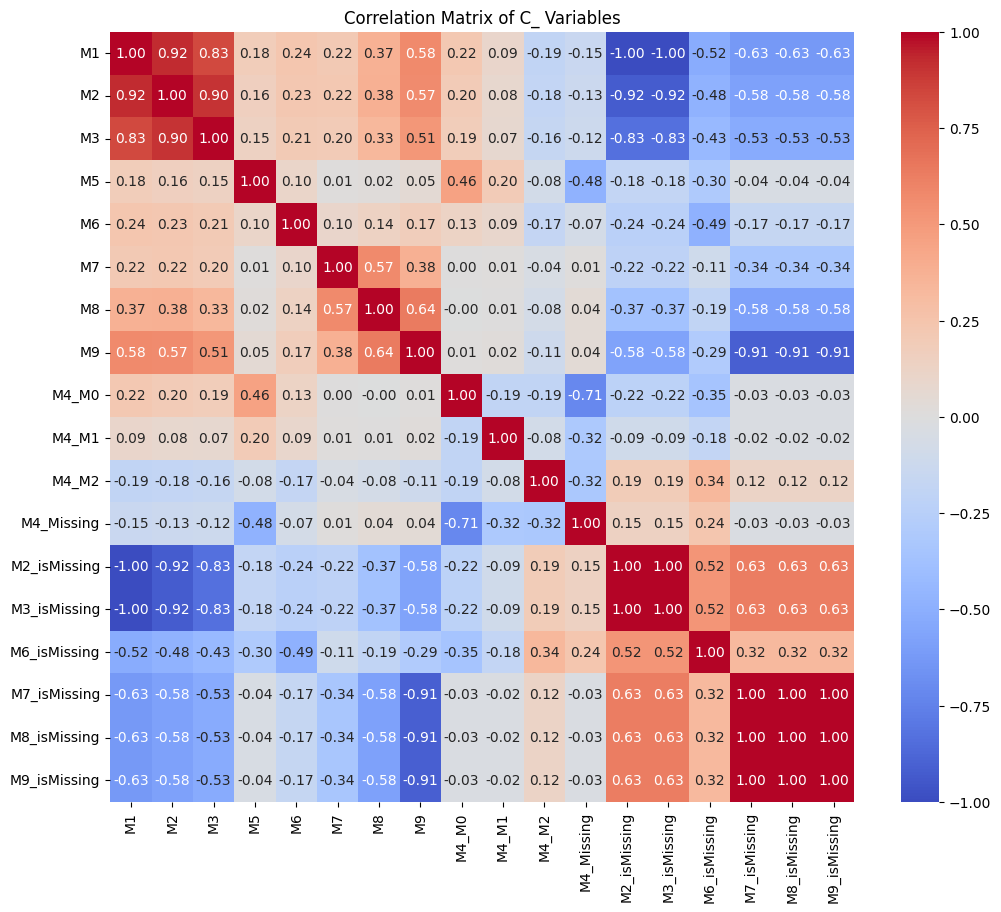

In [40]:
mat_corr(df_transac, 'M')

We can see that for M7, M8 and M9, values are missing in the same time. We can then delete two of them because it is the same information.
Missing values from M2 and M3 are also the same, and correlated with M1. We will then delete all of them (M2_isMissing, M3_isMissing, M8_isMissing, M9_isMissing)

M1, M2 and M3 are really close.

In [41]:
df_transac = df_transac.drop(columns=['M2_isMissing', 'M3_isMissing', 'M8_isMissing', 'M9_isMissing'])

/Users/leadervieux/Documents/StageB/project/func.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/Users/leadervieux/Documents/StageB/project/func.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/Users/leadervieux/Documents/StageB/project/func.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/Users/leadervieux/Documents/StageB/project/func.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


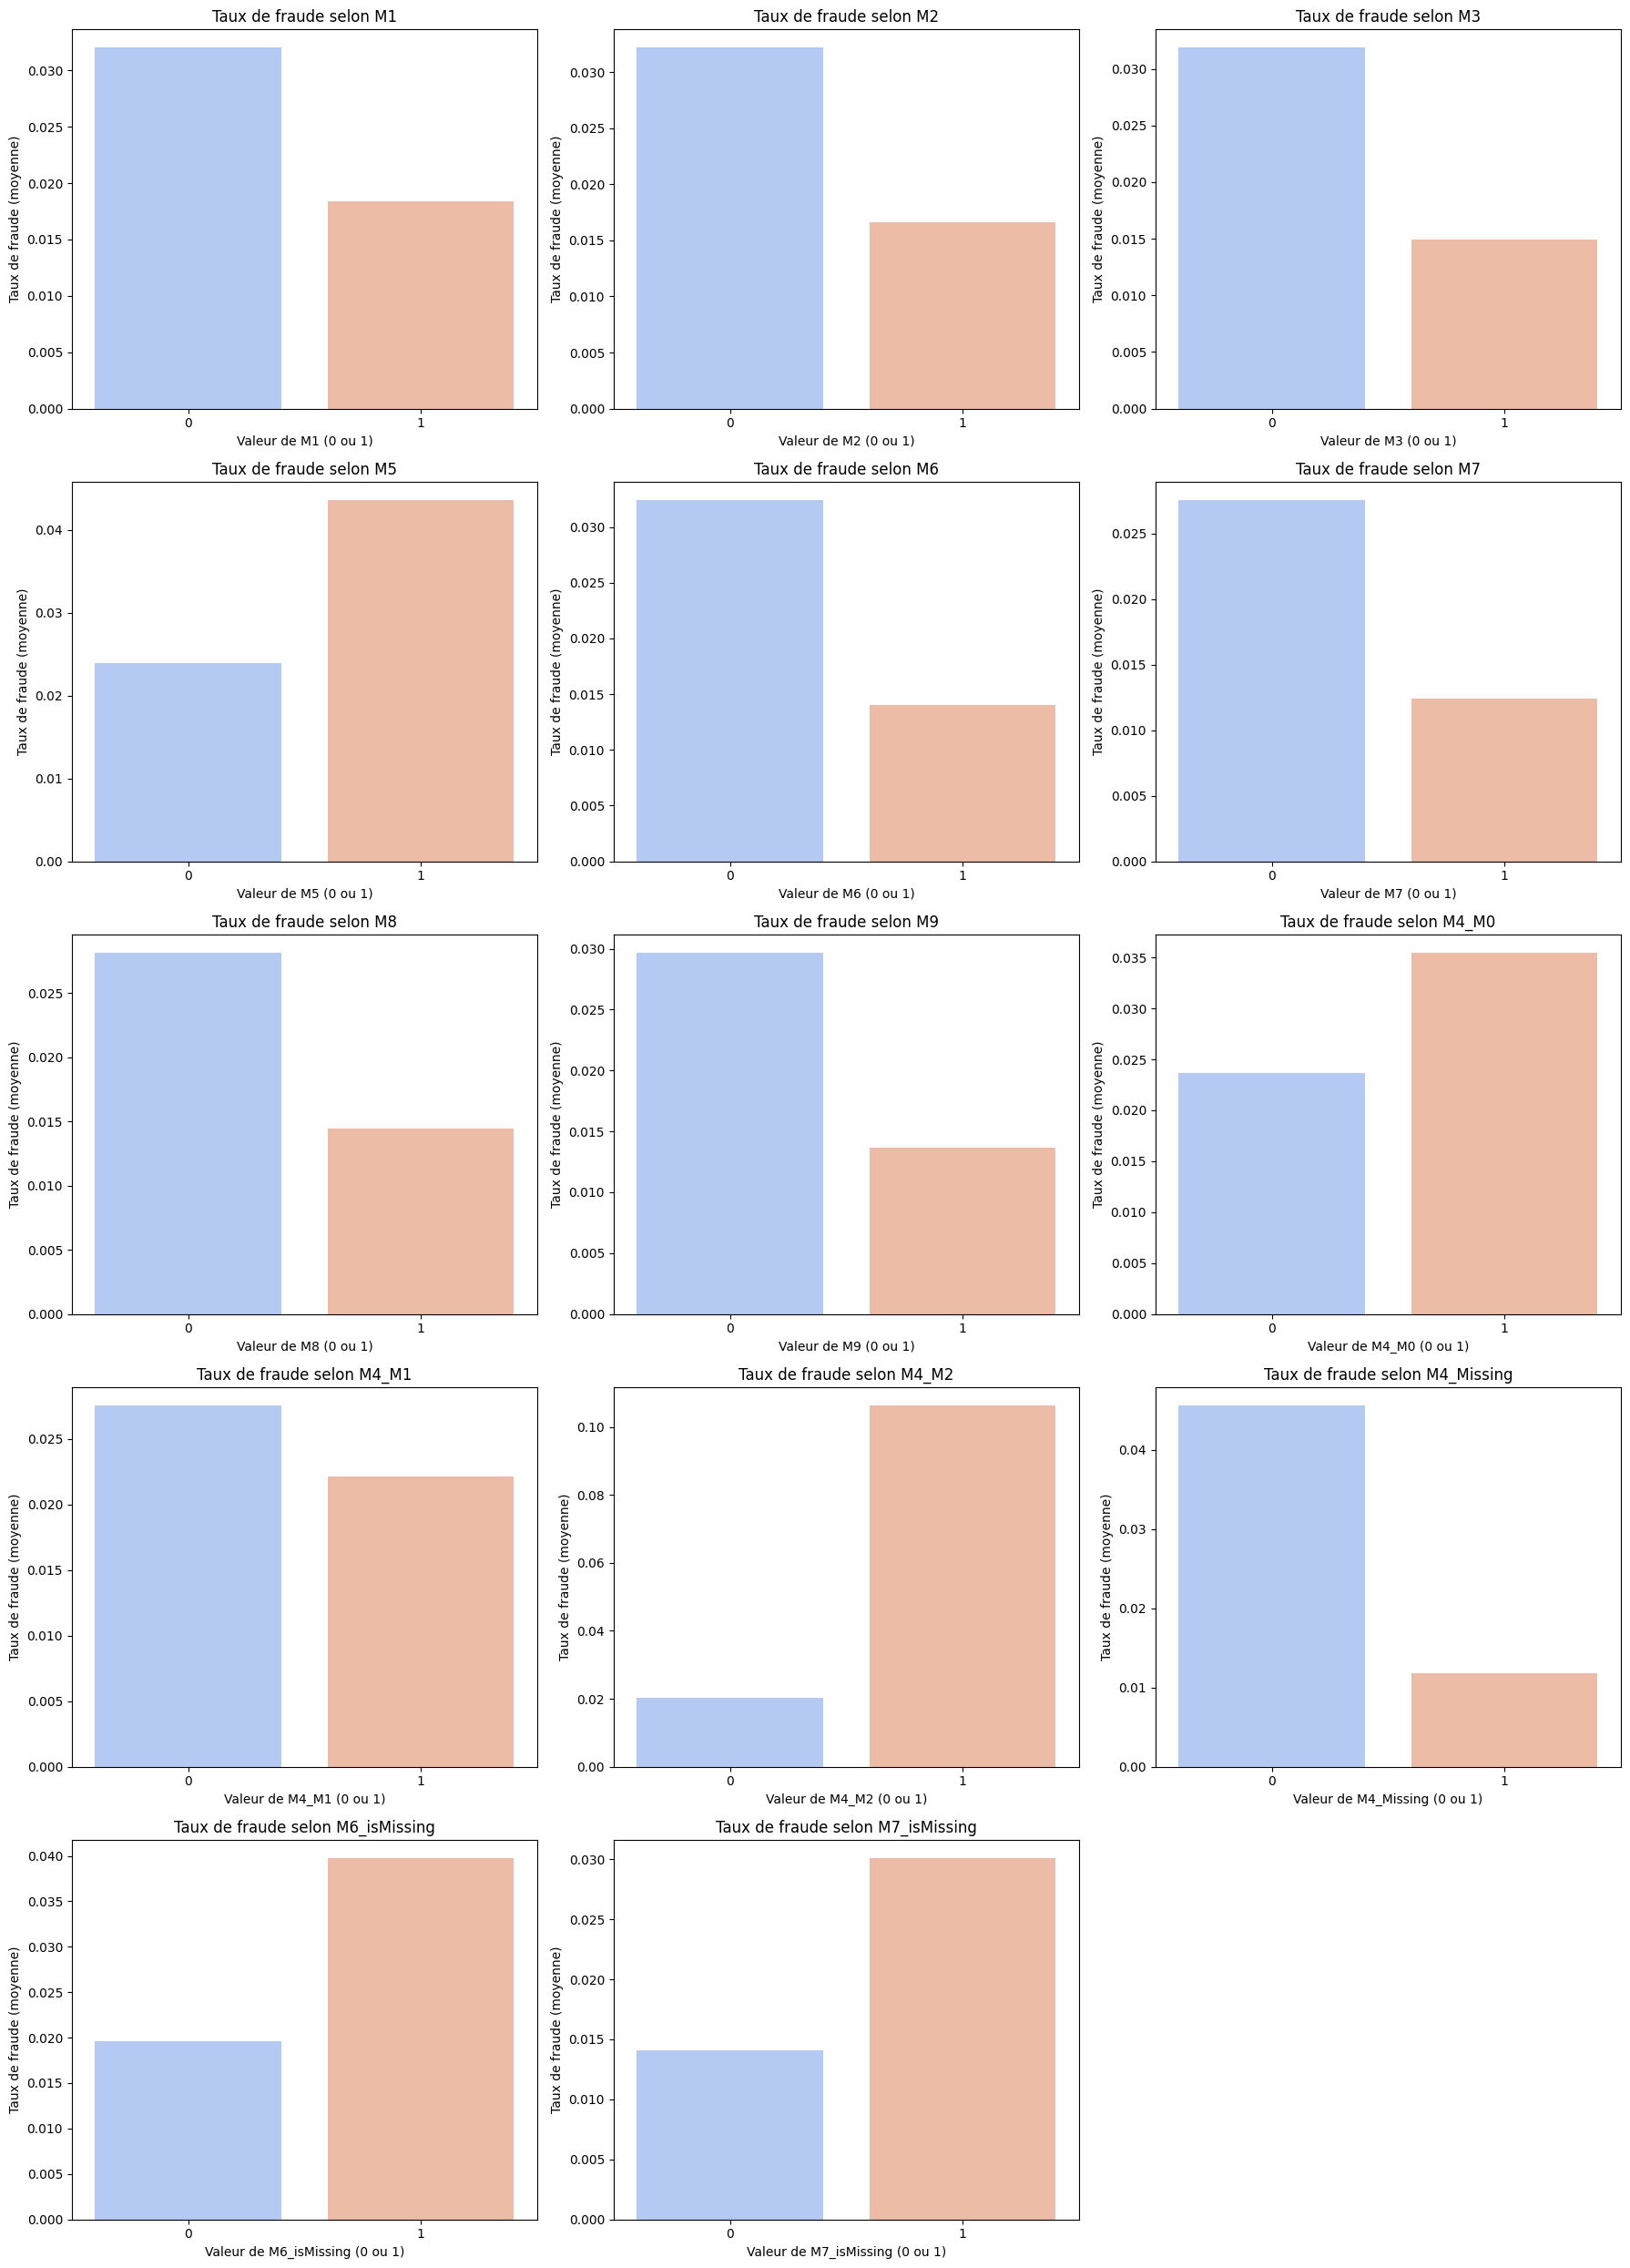

In [42]:
distribution_bin(df_transac, 'M')

Distribution is the same for a lot of variables (like M8 and M9).

Now, variables V

In [43]:
df_V = df_transac.filter(regex='^V', axis=1).copy()
print(df_V.head)

#summary of variables M_ in df_transac
print(df_V.describe())

<bound method NDFrame.head of         V1   V2   V3   V4   V5   V6   V7   V8   V9  V10  ...  V330  V331  \
0      1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  0.0  ...   NaN   NaN   
1      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   NaN   NaN   
2      1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  0.0  ...   NaN   NaN   
3      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   NaN   NaN   
4      NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   0.0   0.0   
...    ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   ...   ...   
49995  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   NaN   NaN   
49996  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   0.0   0.0   
49997  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   NaN   NaN   
49998  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   NaN   NaN   
49999  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   0.0   0.0   

       V332  V333  V334  V335  V336  V337  V338  V339  
0

In [54]:
# 1. On crée une matrice de booléens (NaN = 1, présent = 0)
isna_matrix = df_transac[cols_v].isna()

# 2. On transpose pour que les lignes soient les colonnes et les colonnes soient les lignes
# Cela permet d'utiliser duplicated() pour trouver les colonnes identiques
duplicated_columns = isna_matrix.T.duplicated()

# 3. On identifie les groupes
# Pour chaque colonne, on regarde avec quelles autres elle est identique
groups = {}
for col in isna_matrix.columns:
    pattern = tuple(isna_matrix[col])
    if pattern not in groups:
        groups[pattern] = []
    groups[pattern].append(col)

# 4. Affichage des résultats
print(f"Nombre de motifs de manquants uniques : {len(groups)}")
for i, (pattern, cols) in enumerate(groups.items()):
    if len(cols) > 1: # On n'affiche que les groupes de 2 colonnes ou plus
        print(f"Groupe {i+1} : {len(cols)} colonnes partagent le même schéma.")

Nombre de motifs de manquants uniques : 12
Groupe 1 : 11 colonnes partagent le même schéma.
Groupe 2 : 23 colonnes partagent le même schéma.
Groupe 3 : 18 colonnes partagent le même schéma.
Groupe 4 : 22 colonnes partagent le même schéma.
Groupe 5 : 20 colonnes partagent le même schéma.
Groupe 6 : 53 colonnes partagent le même schéma.
Groupe 7 : 29 colonnes partagent le même schéma.
Groupe 8 : 50 colonnes partagent le même schéma.
Groupe 9 : 46 colonnes partagent le même schéma.
Groupe 10 : 16 colonnes partagent le même schéma.
Groupe 11 : 32 colonnes partagent le même schéma.
Groupe 12 : 18 colonnes partagent le même schéma.


In [55]:
# 1. On récupère les groupes (ici j'utilise ton résultat)
# On crée un dictionnaire où la clé est le motif (pattern) et la valeur est la liste des colonnes
# (Le code que tu as lancé précédemment a dû te générer ce dictionnaire 'groups')

# 2. Création des flags de groupe
for i, (pattern, cols) in enumerate(groups.items()):
    # On crée le nom du flag
    flag_name = f'V_Pattern_{i+1}_isMissing'
    
    # On regarde si l'une des colonnes du groupe est manquante (any)
    # C'est plus robuste que de tester chaque colonne individuellement
    df_transac[flag_name] = df_transac[cols].isna().any(axis=1).astype(int)

print("Les 12 flags de groupes ont été créés avec succès.")

Les 12 flags de groupes ont été créés avec succès.


In [56]:
print(df_transac)

       TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0            2987000        0          86400          68.500         W  13926   
1            2987001        0          86401          29.000         W   2755   
2            2987002        0          86469          59.000         W   4663   
3            2987003        0          86499          50.000         W  18132   
4            2987004        0          86506          50.000         H   4497   
...              ...      ...            ...             ...       ...    ...   
49995        3036995        0        1189287         117.000         W  17188   
49996        3036996        0        1189295         200.000         R  15063   
49997        3036997        0        1189302         648.420         W   1333   
49998        3036998        0        1189311          21.221         C  12722   
49999        3036999        0        1189336         125.000         R   2616   

       card2  card3       c